<a href="https://colab.research.google.com/github/nicolasaalves/Checkpoint-3---Engenharia-de-Software/blob/main/Aula_05_(18_03).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercício Prático - Do Miro ao Python

**Contexto:** Modelar e implementar um Sistema de Biblioteca Digital (Tipo Kindle Unlimited)

## **Parte 1:** Diagrama no Miro e Draw.io
**Atores:** Leitor, Bibliotecário, Sistema de Pagamento

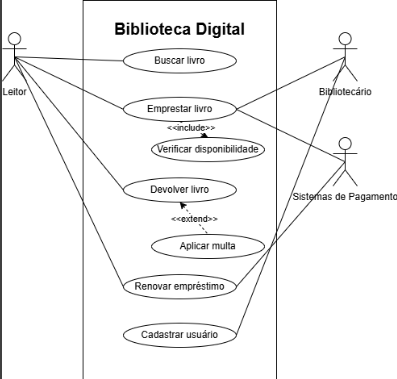

## **Parte 2:** Especificação
Documentando o UC: "Emprestar Livro"

**UC-02:** Emprestar Livro

---



**Ator:** Leitor

---



**Pré-condições:**

O leitor deve estar cadastrado no sistema.

O livro deve estar registrado na biblioteca.

O livro deve estar disponível para empréstimo.

O leitor não pode possuir pendências, como multas em aberto ou limite de empréstimos atingido

---



**Fluxo Principal:**

O leitor acessa a funcionalidade Emprestar livro no sistema.

O sistema realiza a verificação de disponibilidade do livro solicitado.

Estando disponível e com o leitor apto, o sistema registra o empréstimo e associa o livro ao leitor.

O sistema informa a data prevista para devolução e confirma a operação.

---



**Fluxo de Exceção:**

Se o livro não estiver disponível, o sistema informa que o empréstimo não pode ser realizado.

Se o leitor possuir multa pendente ou estiver impedido de realizar novos empréstimos, o sistema bloqueia a operação e exibe a mensagem correspondente.

Se houver falha no cadastro do leitor ou do livro, o sistema cancela o processo.

---



**Pós-condições:**

O empréstimo é registrado no sistema.

O status do livro é alterado para emprestado.

O leitor passa a ter um empréstimo ativo vinculado ao seu cadastro.

## Parte 3: Implementação em Python

In [1]:
# ============================================================
# 🏛️ SISTEMA DE BIBLIOTECA DIGITAL — Biblioteca FIAP
# Cada seção = um Caso de Uso do diagrama que você fez no Miro
# ============================================================

# ----------------------------
# 📦 DADOS DO SISTEMA
# (imagine como o "banco de dados" por enquanto)
# ----------------------------
catalogo = [
    {"titulo": "Clean Code", "autor": "Robert C. Martin", "disponivel": True},
    {"titulo": "The Pragmatic Programmer", "autor": "Hunt & Thomas", "disponivel": True},
    {"titulo": "Design Patterns", "autor": "Gang of Four", "disponivel": True},
]

emprestimos = []   # lista de {"leitor": ..., "livro": ...}

# ============================================================
# UC-01: LISTAR CATÁLOGO
# Ator: Leitor
# ============================================================
print("📚 Catálogo disponível:")
for livro in catalogo:
    status = "✅" if livro["disponivel"] else "❌"
    print(f"  {status} {livro['titulo']} — {livro['autor']}")

# ============================================================
# UC-02: BUSCAR LIVRO
# Ator: Leitor
# Pré-condição: catálogo não vazio
# ============================================================
print("\n🔍 Buscando livro...")
busca = "clean"   # o leitor digitou isso

encontrou = False

for livro in catalogo:
    if busca.lower() in livro["titulo"].lower():
        status = "✅" if livro["disponivel"] else "❌"
        print(f"  {status} {livro['titulo']} — {livro['autor']}")
        encontrou = True

if encontrou == False:
    print("❌ Nenhum livro encontrado com esse termo.")

# ============================================================
# UC-03: EMPRESTAR LIVRO
# Ator: Leitor
# <<include>> UC-04 Verificar Disponibilidade
# ============================================================
print("\n📌 Empréstimo:")
leitor = "Ana Silva"
titulo = "Clean Code"

# <<include>> — verificar disponibilidade (sempre acontece)
livro_encontrado = None

for livro in catalogo:
    if livro["titulo"] == titulo:
        livro_encontrado = livro
        break

if livro_encontrado is None:
    print("❌ Livro não encontrado no catálogo.")
elif livro_encontrado["disponivel"] == False:
    # Fluxo de exceção
    print(f"⚠️  '{titulo}' já está emprestado!")
else:
    # Fluxo principal
    livro_encontrado["disponivel"] = False
    emprestimos.append({"leitor": leitor, "livro": titulo})
    print(f"✅ '{titulo}' emprestado para {leitor}!")

# ============================================================
# UC-04: DEVOLVER LIVRO
# Ator: Leitor
# <<extend>> UC-05 Aplicar Multa (só se atrasado)
# ============================================================
print("\n🔄 Devolução:")
leitor_devolvendo = "Ana Silva"
titulo_devolvendo = "Clean Code"

registro_encontrado = None

# 1. Procurar o empréstimo correspondente
for emprestimo in emprestimos:
    if emprestimo["leitor"] == leitor_devolvendo and emprestimo["livro"] == titulo_devolvendo:
        registro_encontrado = emprestimo
        break

# 2. Se encontrado: devolver livro e remover empréstimo
if registro_encontrado is not None:
    for livro in catalogo:
        if livro["titulo"] == titulo_devolvendo:
            livro["disponivel"] = True
            break

    emprestimos.remove(registro_encontrado)
    print(f"✅ '{titulo_devolvendo}' devolvido por {leitor_devolvendo}!")

    # Bônus <<extend>>: verificar atraso
    houve_atraso = "sim"   # pode trocar para "nao"
    if houve_atraso.lower() == "sim":
        print("📋 Multa aplicada!")

# 3. Se não encontrado: erro
else:
    print("❌ Empréstimo não encontrado. Não é possível devolver este livro.")

# ============================================================
# 🔎 ESTADO FINAL — confira o resultado
# ============================================================
print("\n📖 Catálogo após operações:")
for livro in catalogo:
    status = "✅" if livro["disponivel"] else "❌"
    print(f"  {status} {livro['titulo']}")

print(f"\n📋 Empréstimos ativos: {emprestimos}")

📚 Catálogo disponível:
  ✅ Clean Code — Robert C. Martin
  ✅ The Pragmatic Programmer — Hunt & Thomas
  ✅ Design Patterns — Gang of Four

🔍 Buscando livro...
  ✅ Clean Code — Robert C. Martin

📌 Empréstimo:
✅ 'Clean Code' emprestado para Ana Silva!

🔄 Devolução:
✅ 'Clean Code' devolvido por Ana Silva!
📋 Multa aplicada!

📖 Catálogo após operações:
  ✅ Clean Code
  ✅ The Pragmatic Programmer
  ✅ Design Patterns

📋 Empréstimos ativos: []
